In [2]:
import json
import os
from typing import Dict, List, Tuple
from collections import defaultdict

## 统计反先验文本替换比例

In [3]:
import re

def count_modified_words(text1, text2):
    # 使用正则表达式提取所有单词（忽略大小写）
    words1 = re.findall(r'\b\w+\b', text1.lower())
    words2 = re.findall(r'\b\w+\b', text2.lower())
    
    # if len(words1) != len(words2):
    #     print("警告：两段文本的单词总数不一致，可能影响准确性。")
    
    total_words = min(len(words1), len(words2))  # 取较小的单词数以避免索引错误
    modified_count = 0
    
    for w1, w2 in zip(words1[:total_words], words2[:total_words]):
        if w1 != w2:
            modified_count += 1
    
    if total_words == 0:
        modification_ratio = 0.0
    else:
        modification_ratio = (modified_count / total_words) * 100
    
    return modified_count, modification_ratio

In [4]:
with open("../fox_data/data.json", "r") as f:
    data = json.load(f)
    
total_modification_ratio = 0
for item in data:
    gt_text = item["gt_text"]
    distorted_text = item["distorted_text"]
    modified_count, modification_ratio = count_modified_words(gt_text, distorted_text)
    total_modification_ratio += modification_ratio
    print(f"Image: {item['image']}")
    print(f"Modified Words: {modified_count}")
    print(f"Modification Ratio: {modification_ratio:.2f}%")
    print("-" * 40)
print(f"Average Modification Ratio: {total_modification_ratio / len(data):.2f}%")

Image: en_1.png
Modified Words: 590
Modification Ratio: 70.66%
----------------------------------------
Image: en_2.png
Modified Words: 110
Modification Ratio: 10.59%
----------------------------------------
Image: en_3.png
Modified Words: 595
Modification Ratio: 84.64%
----------------------------------------
Image: en_4.png
Modified Words: 540
Modification Ratio: 86.82%
----------------------------------------
Image: en_5.png
Modified Words: 317
Modification Ratio: 59.36%
----------------------------------------
Image: en_6.png
Modified Words: 697
Modification Ratio: 96.81%
----------------------------------------
Image: en_7.png
Modified Words: 224
Modification Ratio: 41.95%
----------------------------------------
Image: en_8.png
Modified Words: 69
Modification Ratio: 9.04%
----------------------------------------
Image: en_9.png
Modified Words: 770
Modification Ratio: 99.87%
----------------------------------------
Image: en_10.png
Modified Words: 538
Modification Ratio: 99.45%
--

## 统计OCR结果

In [5]:
def analyze_evaluation_results(file_path: str) -> Tuple[Dict[str, Dict[str, float]], float]:
    """
    分析评估结果文件,按token_count分组统计precision
    
    Args:
        file_path: JSON评估结果文件路径
        
    Returns:
        分组统计结果字典(包含平均precision和样本数)和整体平均precision
    """
    # 读取JSON文件
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 用于存储每个分组的precision值
    grouped_precisions = defaultdict(list)
    
    # 遍历数据(除了最后一个overall_metrics)
    for item in data[:-1]:
        if 'token_count' in item and 'precision' in item:
            token_count = item['token_count']
            precision = item['precision']
            
            # 确定所属的分组(向下取整到百位)
            group_start = (token_count // 100) * 100
            group_end = group_start + 100
            group_key = f"{group_start}-{group_end}"
            
            grouped_precisions[group_key].append(precision)
    
    # 计算每个分组的平均precision和样本数，并按起始数值排序
    group_stats = {}
    # 按group_start数值排序
    sorted_groups = sorted(grouped_precisions.items(), key=lambda x: int(x[0].split('-')[0]))
    
    for group_key, precisions in sorted_groups:
        avg_precision = sum(precisions) / len(precisions)
        sample_count = len(precisions)
        group_stats[group_key] = {
            'avg_precision': avg_precision,
            'sample_count': sample_count
        }
    
    # 获取整体平均precision
    overall_precision = data[-1]['overall_metrics']['precision']
    
    return group_stats, overall_precision


def print_analysis_results(file_path: str):
    """
    打印分析结果
    
    Args:
        file_path: JSON评估结果文件路径
    """
    group_results, overall_precision = analyze_evaluation_results(file_path)
    
    print("=" * 70)
    print("按Token数量分组的Precision统计")
    print("=" * 70)
    
    for group_range, stats in group_results.items():
        avg_precision = stats['avg_precision']
        sample_count = stats['sample_count']
        print(f"Token范围 {group_range:12s} 样本数 = {sample_count:3d} 平均Precision = {avg_precision:.4f} ")
    
    print("=" * 70)
    print(f"整体平均Precision: {overall_precision:.4f}")
    print("=" * 70)

In [3]:
print_analysis_results("../results/ocr/en_png_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9593 
Token范围 700-800      样本数 =  28 平均Precision = 0.9381 
Token范围 800-900      样本数 =  28 平均Precision = 0.9191 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8419 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7924 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7434 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.5873 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6934 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.7670 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.3441 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5814 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3443 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0043 
整体平均Precision: 0.8388


In [4]:
print_analysis_results("../results/ocr/en_png_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9830 
Token范围 700-800      样本数 =  28 平均Precision = 0.9698 
Token范围 800-900      样本数 =  28 平均Precision = 0.9665 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9668 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9125 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8921 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8644 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9098 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9603 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7601 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8618 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.7629 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3724 
整体平均Precision: 0.9389


In [26]:
print_analysis_results("../results/ocr/en_png_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9211 
Token范围 700-800      样本数 =  28 平均Precision = 0.8551 
Token范围 800-900      样本数 =  28 平均Precision = 0.8118 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8338 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.8089 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8865 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6328 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6589 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9333 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5140 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5803 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9301 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0287 
整体平均Precision: 0.8097


In [10]:
print_analysis_results("../results/ocr/en_png_1024_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9851 
Token范围 700-800      样本数 =  28 平均Precision = 0.9765 
Token范围 800-900      样本数 =  28 平均Precision = 0.9774 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9880 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9527 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9367 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8965 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9605 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9947 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9223 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9402 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9578 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.7360 
整体平均Precision: 0.9662


In [5]:
print_analysis_results("../results/ocr/from_text_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9864 
Token范围 700-800      样本数 =  28 平均Precision = 0.9670 
Token范围 800-900      样本数 =  28 平均Precision = 0.9446 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8773 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.8618 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8072 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.7397 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6422 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.6448 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5359 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.6450 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.6000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.1366 
整体平均Precision: 0.8800


In [6]:
print_analysis_results("../results/ocr/from_text_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9900 
Token范围 700-800      样本数 =  28 平均Precision = 0.9848 
Token范围 800-900      样本数 =  28 平均Precision = 0.9749 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9694 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9524 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9421 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9185 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8761 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9086 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.8441 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8701 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.7434 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.1361 
整体平均Precision: 0.9523


In [6]:
print_analysis_results("../results/ocr/from_text_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7988 
Token范围 700-800      样本数 =  28 平均Precision = 0.7007 
Token范围 800-900      样本数 =  28 平均Precision = 0.7696 
Token范围 900-1000     样本数 =  14 平均Precision = 0.7482 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.6765 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.6393 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8292 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8570 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.7633 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.6204 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.7533 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8108 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4226 
整体平均Precision: 0.7334


In [14]:
print_analysis_results("../results/ocr/from_text_1024_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9956 
Token范围 700-800      样本数 =  28 平均Precision = 0.9882 
Token范围 800-900      样本数 =  28 平均Precision = 0.9875 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9894 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9667 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9546 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9339 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9816 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9868 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9583 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9713 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9429 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8400 
整体平均Precision: 0.9793


In [7]:
print_analysis_results("../results/ocr/distort_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7141 
Token范围 700-800      样本数 =  28 平均Precision = 0.6254 
Token范围 800-900      样本数 =  28 平均Precision = 0.6149 
Token范围 900-1000     样本数 =  14 平均Precision = 0.5844 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.6296 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.4972 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.4470 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.4836 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.0177 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4206 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3451 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2593 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4257 
整体平均Precision: 0.5826


In [ ]:
print_analysis_results("../results/ocr/distort_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7205 
Token范围 700-800      样本数 =  28 平均Precision = 0.6412 
Token范围 800-900      样本数 =  28 平均Precision = 0.6431 
Token范围 900-1000     样本数 =  14 平均Precision = 0.6835 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7054 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7161 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6287 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6651 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.4410 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.6941 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.4488 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.5443 
整体平均Precision: 0.6551


In [7]:
print_analysis_results("../results/ocr/distort_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.5865 
Token范围 700-800      样本数 =  28 平均Precision = 0.4924 
Token范围 800-900      样本数 =  28 平均Precision = 0.5447 
Token范围 900-1000     样本数 =  14 平均Precision = 0.4867 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.5675 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.5511 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.4544 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.5640 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.4805 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.3811 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3474 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3478 
整体平均Precision: 0.5137


In [4]:
print_analysis_results("../results/distort/distort_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9623 
Token范围 700-800      样本数 =  28 平均Precision = 0.8794 
Token范围 800-900      样本数 =  28 平均Precision = 0.8846 
Token范围 900-1000     样本数 =  14 平均Precision = 0.7006 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7454 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.5776 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.5426 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.5049 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.0194 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4675 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.4412 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2593 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4059 
整体平均Precision: 0.7675


In [6]:
print_analysis_results("../results/distort/distort_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9878 
Token范围 700-800      样本数 =  28 平均Precision = 0.9408 
Token范围 800-900      样本数 =  28 平均Precision = 0.9691 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9011 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9205 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8711 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9023 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8122 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.7333 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.8046 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.7954 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.6392 
整体平均Precision: 0.9156


In [7]:
print_analysis_results("../results/distort/distort_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7579 
Token范围 700-800      样本数 =  28 平均Precision = 0.6704 
Token范围 800-900      样本数 =  28 平均Precision = 0.7419 
Token范围 900-1000     样本数 =  14 平均Precision = 0.6980 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7639 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7164 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6349 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8255 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.8745 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5374 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.6020 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4783 
整体平均Precision: 0.7058


In [16]:
print_analysis_results("../results/ocr/distort_1024_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9960 
Token范围 700-800      样本数 =  28 平均Precision = 0.9812 
Token范围 800-900      样本数 =  28 平均Precision = 0.9920 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9820 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9632 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9503 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9762 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9605 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9675 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9818 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9697 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.4314 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8105 
整体平均Precision: 0.9731


## 统计QA结果

In [9]:
import numpy as np

In [10]:
def qa_eval(y_true, y_pred):
    pass

In [25]:
with open("../results/qa/qa_recheck_single_mode__DeepSeek-OCR.json", 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# 统计TP, FP, TN, FN，并根据此计算准确率、精确率、召回率和F1分数
TP = 0
FP = 0
TN = 0
FN = 0

for item in qa_data:
    qa_pairs = item["qa_pairs"]
    for qa in qa_pairs:
        pred_answer = qa["LLMAnswer"]
        if pred_answer is None:
            clean_answer = ""
        else:
            clean_answer = pred_answer[0].strip()
        if clean_answer == qa["correct_answer"]:
            TP += 1
        else:
            FP += 1

# 计算指标
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.2768
Precision: 0.2768
Recall: 1.0000
F1 Score: 0.4336


In [22]:
with open("../results/qa/qa_recheck_single_mode__Qwen2.5-3B-Instruct.json", 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# 统计TP, FP, TN, FN，并根据此计算准确率、精确率、召回率和F1分数
TP = 0
FP = 0
TN = 0
FN = 0

for item in qa_data:
    qa_pairs = item["qa_pairs"]
    for qa in qa_pairs:
        pred_answer = qa["LLMAnswer"]
        if pred_answer is None:
            clean_answer = ""
        else:
            clean_answer = pred_answer[0].strip()
        if clean_answer == qa["correct_answer"]:
            TP += 1
        else:
            FP += 1

# 计算指标
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.9405
Precision: 0.9405
Recall: 1.0000
F1 Score: 0.9693


In [23]:
with open("../results/qa/qa_recheck_single_mode__Qwen3-4B-Instruct-2507.json", 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# 统计TP, FP, TN, FN，并根据此计算准确率、精确率、召回率和F1分数
TP = 0
FP = 0
TN = 0
FN = 0

for item in qa_data:
    qa_pairs = item["qa_pairs"]
    for qa in qa_pairs:
        pred_answer = qa["LLMAnswer"]
        if pred_answer is None:
            clean_answer = ""
        else:
            clean_answer = pred_answer[0].strip()
        if clean_answer == qa["correct_answer"]:
            TP += 1
        else:
            FP += 1

# 计算指标
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.9881
Precision: 0.9881
Recall: 1.0000
F1 Score: 0.9940


In [24]:
with open("../results/qa/qa_recheck_single_mode__Llama-3.2-3B-Instruct.json", 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# 统计TP, FP, TN, FN，并根据此计算准确率、精确率、召回率和F1分数
TP = 0
FP = 0
TN = 0
FN = 0

for item in qa_data:
    qa_pairs = item["qa_pairs"]
    for qa in qa_pairs:
        pred_answer = qa["LLMAnswer"]
        if pred_answer is None:
            clean_answer = ""
        else:
            clean_answer = pred_answer[0].strip()
        if clean_answer == qa["correct_answer"]:
            TP += 1
        else:
            FP += 1

# 计算指标
accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Accuracy: 0.9226
Precision: 0.9226
Recall: 1.0000
F1 Score: 0.9598


## 统计 VQA

In [86]:
def eval_vqa(file_path:str):
    with open(file_path, 'r', encoding='utf-8') as f:
        qa_data = json.load(f)

    count = 0

    # 统计TP, FP, TN, FN，并根据此计算准确率、精确率、召回率和F1分数
    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for item in qa_data:
        qa_pairs = item["qa_pairs"]
        for qa in qa_pairs:
            pred_answer = qa["LLMAnswer"]
            if pred_answer is None:
                clean_answer = ""
            else:
                clean_answer = pred_answer[0].strip()
                if clean_answer not in ["A", "B", "C", "D"]:
                    clean_answer = ""
                    count += 1
                    # break
            if clean_answer == qa["correct_answer"]:
                TP += 1
            else:
                FP += 1

    # 计算指标
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Unexpected answers count: {count}")

In [17]:
eval_vqa("../results/vqa/en_png_tiny.json")

Accuracy: 0.1994
Unexpected answers count: 33


In [18]:
eval_vqa("../results/vqa/en_png_small.json")

Accuracy: 0.1845
Unexpected answers count: 9


In [19]:
eval_vqa("../results/vqa/en_png_raw.json")

Accuracy: 0.2143
Unexpected answers count: 0


In [20]:
eval_vqa("../results/vqa/from_text_tiny.json")

Accuracy: 0.1964
Unexpected answers count: 9


In [21]:
eval_vqa("../results/vqa/from_text_small.json")

Accuracy: 0.2143
Unexpected answers count: 0


In [23]:
eval_vqa("../results/vqa/from_text_raw.json")

Accuracy: 0.2232
Unexpected answers count: 1


In [24]:
eval_vqa("../results/vqa/distort_tiny.json")

Accuracy: 0.1994
Unexpected answers count: 6


In [25]:
eval_vqa("../results/vqa/distort_small.json")

Accuracy: 0.2232
Unexpected answers count: 2


In [26]:
eval_vqa("../results/vqa/distort_raw.json")

Accuracy: 0.2173
Unexpected answers count: 1


In [89]:
eval_vqa("../results/vqa/qwen2.5_vl_3B_vqa_results.json")

Accuracy: 0.2560
Unexpected answers count: 0


In [90]:
eval_vqa("../results/vqa/qwen2.5_vl_7B_vqa_results.json")

Accuracy: 0.2560
Unexpected answers count: 1


In [92]:
eval_vqa("../results/vqa/qwen3_vl_4B_vqa_results.json")

Accuracy: 0.2738
Unexpected answers count: 0


In [93]:
eval_vqa("../results/vqa/qwen3_vl_8B_vqa_results.json")

Accuracy: 0.2798
Unexpected answers count: 1


In [94]:
eval_vqa("../results/vqa/minicpm_v_vqa_results.json")

Accuracy: 0.2321
Unexpected answers count: 0


## 统计replace

In [24]:
print_analysis_results("../results/replace/swap/swap_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9014 
Token范围 700-800      样本数 =  28 平均Precision = 0.8782 
Token范围 800-900      样本数 =  28 平均Precision = 0.8629 
Token范围 900-1000     样本数 =  14 平均Precision = 0.7306 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7716 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7462 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.4884 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.5817 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.6494 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5110 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.4152 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3187 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0530 
整体平均Precision: 0.7811


In [25]:
print_analysis_results("../results/replace/swap/swap_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9260 
Token范围 700-800      样本数 =  28 平均Precision = 0.8982 
Token范围 800-900      样本数 =  28 平均Precision = 0.9084 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8891 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.8809 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8709 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8585 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8099 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.8689 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7337 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.7964 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.5915 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4686 
整体平均Precision: 0.8807


In [26]:
print_analysis_results("../results/replace/swap/swap_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9551 
Token范围 700-800      样本数 =  28 平均Precision = 0.9403 
Token范围 800-900      样本数 =  28 平均Precision = 0.9445 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9390 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9207 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9293 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9493 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9328 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9387 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9161 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9227 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8609 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8919 
整体平均Precision: 0.9375


In [29]:
print_analysis_results("../results/replace/shuffle/shuffle_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.8737 
Token范围 700-800      样本数 =  28 平均Precision = 0.8581 
Token范围 800-900      样本数 =  28 平均Precision = 0.8317 
Token范围 900-1000     样本数 =  14 平均Precision = 0.7748 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7393 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7287 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6256 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.5658 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.2523 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4032 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.4350 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3793 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0194 
整体平均Precision: 0.7670


In [30]:
print_analysis_results("../results/replace/shuffle/shuffle_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9183 
Token范围 700-800      样本数 =  28 平均Precision = 0.8853 
Token范围 800-900      样本数 =  28 平均Precision = 0.8955 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8732 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.8540 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8476 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8305 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.7839 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.8266 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7156 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.7812 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.6154 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.5654 
整体平均Precision: 0.8655


In [31]:
print_analysis_results("../results/replace/shuffle/shuffle_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9672 
Token范围 700-800      样本数 =  28 平均Precision = 0.9416 
Token范围 800-900      样本数 =  28 平均Precision = 0.9556 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9302 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9263 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9326 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9285 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9284 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9065 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9269 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9342 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8469 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8776 
整体平均Precision: 0.9399


In [32]:
print_analysis_results("../results/replace/swap_5/swap_5_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9419 
Token范围 700-800      样本数 =  28 平均Precision = 0.9202 
Token范围 800-900      样本数 =  28 平均Precision = 0.9082 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8421 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.8142 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7813 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6970 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6107 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.6763 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.3738 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5571 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2545 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3111 
整体平均Precision: 0.8369


In [33]:
print_analysis_results("../results/replace/swap_5/swap_5_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9521 
Token范围 700-800      样本数 =  28 平均Precision = 0.9494 
Token范围 800-900      样本数 =  28 平均Precision = 0.9392 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9231 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9173 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8998 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8708 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8531 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9158 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7882 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8386 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2105 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.6050 
整体平均Precision: 0.9151


In [34]:
print_analysis_results("../results/replace/swap_5/swap_5_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9655 
Token范围 700-800      样本数 =  28 平均Precision = 0.9594 
Token范围 800-900      样本数 =  28 平均Precision = 0.9616 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9572 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9449 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9408 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9456 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9542 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9542 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9192 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9551 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8966 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8818 
整体平均Precision: 0.9545


In [36]:
print_analysis_results("../results/replace/shuffle_5/shuffle_5_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9306 
Token范围 700-800      样本数 =  28 平均Precision = 0.9070 
Token范围 800-900      样本数 =  28 平均Precision = 0.8745 
Token范围 900-1000     样本数 =  14 平均Precision = 0.8285 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.7941 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7331 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.7108 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.6087 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.6604 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.3255 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5963 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3594 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3043 
整体平均Precision: 0.8183


In [37]:
print_analysis_results("../results/replace/shuffle_5/shuffle_5_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9519 
Token范围 700-800      样本数 =  28 平均Precision = 0.9376 
Token范围 800-900      样本数 =  28 平均Precision = 0.9386 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9226 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9068 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8908 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8652 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.8464 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.8903 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7729 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8188 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.6607 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.5475 
整体平均Precision: 0.9124


In [38]:
print_analysis_results("../results/replace/shuffle_5/shuffle_5_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9684 
Token范围 700-800      样本数 =  28 平均Precision = 0.9649 
Token范围 800-900      样本数 =  28 平均Precision = 0.9698 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9603 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9477 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9444 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9482 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9464 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9471 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9258 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9563 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8947 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8349 
整体平均Precision: 0.9584


## 统计Random

In [4]:
print_analysis_results("../results/random/random_tiny_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.2681 
Token范围 700-800      样本数 =  28 平均Precision = 0.2429 
Token范围 800-900      样本数 =  28 平均Precision = 0.2277 
Token范围 900-1000     样本数 =  13 平均Precision = 0.2344 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.1544 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.1521 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.1120 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.0840 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.0523 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.0248 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.0443 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0286 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0000 
整体平均Precision: 0.1984


In [7]:
print_analysis_results("../results/random/random_small_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.4537 
Token范围 700-800      样本数 =  28 平均Precision = 0.4525 
Token范围 800-900      样本数 =  28 平均Precision = 0.4653 
Token范围 900-1000     样本数 =  13 平均Precision = 0.4244 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.4315 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.4035 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.3348 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.3302 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.2587 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.2321 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.2400 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.1891 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0697 
整体平均Precision: 0.4212


In [8]:
print_analysis_results("../results/random/random_raw_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.6354 
Token范围 700-800      样本数 =  28 平均Precision = 0.6193 
Token范围 800-900      样本数 =  28 平均Precision = 0.6347 
Token范围 900-1000     样本数 =  13 平均Precision = 0.6094 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.6107 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.6160 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.6018 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.6236 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.5828 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5783 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5605 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.5664 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4560 
整体平均Precision: 0.6170


## 对比其他ocr和vlm模型

In [ ]:
print_analysis_results("../results/other/glmocr_ocr_from_text_eval.json")

In [6]:
print_analysis_results("../results/other/random_dotsocr_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.4680 
Token范围 700-800      样本数 =  28 平均Precision = 0.4777 
Token范围 800-900      样本数 =  28 平均Precision = 0.4883 
Token范围 900-1000     样本数 =  13 平均Precision = 0.4397 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.4669 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.4565 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.4398 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.4026 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.4416 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4095 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3935 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3888 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3289 
整体平均Precision: 0.4631


In [7]:
print_analysis_results("../results/other/qwen2.5_vl_7B_random_ocr_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.5120 
Token范围 700-800      样本数 =  28 平均Precision = 0.5049 
Token范围 800-900      样本数 =  28 平均Precision = 0.5054 
Token范围 900-1000     样本数 =  13 平均Precision = 0.4411 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.3883 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.4988 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.3800 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.3778 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.4345 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4866 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.2422 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.4189 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.4487 
整体平均Precision: 0.4686


In [56]:
print_analysis_results("../results/other/qwen2.5_vl_72B_random_ocr_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.5861 
Token范围 700-800      样本数 =  28 平均Precision = 0.5614 
Token范围 800-900      样本数 =  28 平均Precision = 0.5811 
Token范围 900-1000     样本数 =  13 平均Precision = 0.5455 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.5935 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.5825 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.5557 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.5410 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.5361 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.5330 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.5174 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.5618 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.5016 
整体平均Precision: 0.5678


In [57]:
print_analysis_results("../results/other/got_ocr_random_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7013 
Token范围 700-800      样本数 =  28 平均Precision = 0.5963 
Token范围 800-900      样本数 =  28 平均Precision = 0.6343 
Token范围 900-1000     样本数 =  13 平均Precision = 0.5750 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.5523 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.5587 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.4934 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.4715 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.4533 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4058 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3560 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.2968 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.1069 
整体平均Precision: 0.5771


In [70]:
print_analysis_results("../results/other/monkeyocr_1.2B_results_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.7177 
Token范围 700-800      样本数 =  28 平均Precision = 0.7163 
Token范围 800-900      样本数 =  28 平均Precision = 0.7253 
Token范围 900-1000     样本数 =  13 平均Precision = 0.7117 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.7207 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.7171 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.7016 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.7091 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.7084 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.6864 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.6774 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.6539 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.6672 
整体平均Precision: 0.7155


In [66]:
print_analysis_results("../results/other/monkeyocr_3B_results_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.8039 
Token范围 700-800      样本数 =  28 平均Precision = 0.7964 
Token范围 800-900      样本数 =  28 平均Precision = 0.8030 
Token范围 900-1000     样本数 =  13 平均Precision = 0.7934 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.8086 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8068 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.7944 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.7997 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.8038 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.7956 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.7664 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.7778 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8013 
整体平均Precision: 0.7997


In [73]:
print_analysis_results("../results/other/minerU_results_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.0461 
Token范围 700-800      样本数 =  28 平均Precision = 0.0301 
Token范围 800-900      样本数 =  28 平均Precision = 0.0439 
Token范围 900-1000     样本数 =  13 平均Precision = 0.0425 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.0409 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.0446 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.0285 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.0086 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.0475 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.0143 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.0000 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0417 
整体平均Precision: 0.0367


In [7]:
print_analysis_results("../results/other/paddle_ocr_random_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.8894 
Token范围 700-800      样本数 =  28 平均Precision = 0.8993 
Token范围 800-900      样本数 =  28 平均Precision = 0.8970 
Token范围 900-1000     样本数 =  13 平均Precision = 0.8959 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.8900 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.8966 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8943 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.8959 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.8996 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.8894 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8755 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.8698 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.8898 
整体平均Precision: 0.8953


In [78]:
print_analysis_results("../results/other/smoldocling_results_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.6645 
Token范围 700-800      样本数 =  28 平均Precision = 0.6110 
Token范围 800-900      样本数 =  28 平均Precision = 0.5828 
Token范围 900-1000     样本数 =  13 平均Precision = 0.5429 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.4534 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.5421 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.5958 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.5803 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.5695 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.4905 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.4603 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.5439 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3857 
整体平均Precision: 0.5677


In [82]:
print_analysis_results("../results/other/nougat_ocr_results_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.4516 
Token范围 700-800      样本数 =  28 平均Precision = 0.3650 
Token范围 800-900      样本数 =  28 平均Precision = 0.4050 
Token范围 900-1000     样本数 =  13 平均Precision = 0.4236 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.3858 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.3959 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.1551 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.3906 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.3657 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.2183 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3774 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3606 
整体平均Precision: 0.3794


In [96]:
print_analysis_results("../results/other/hunyuan_ocr_random_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.4780 
Token范围 700-800      样本数 =  28 平均Precision = 0.4076 
Token范围 800-900      样本数 =  28 平均Precision = 0.3598 
Token范围 900-1000     样本数 =  13 平均Precision = 0.3595 
Token范围 1000-1100    样本数 =  12 平均Precision = 0.3844 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.3645 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.3867 
Token范围 1300-1400    样本数 =   4 平均Precision = 0.3421 
Token范围 1400-1500    样本数 =   2 平均Precision = 0.3429 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.3151 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.3612 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.3045 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.3111 
整体平均Precision: 0.3804


### from_text

In [8]:
print_analysis_results("../results/other/qwen2.5_vl_7B_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9952 
Token范围 700-800      样本数 =  28 平均Precision = 0.9802 
Token范围 800-900      样本数 =  28 平均Precision = 0.9823 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9898 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9697 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9673 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9829 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9805 
Token范围 1400-1500    样本数 =   1 平均Precision = 1.0000 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9785 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9729 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9649 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9943 
整体平均Precision: 0.9810


In [9]:
print_analysis_results("../results/other/qwen2.5_vl_72B_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9973 
Token范围 700-800      样本数 =  28 平均Precision = 0.9833 
Token范围 800-900      样本数 =  28 平均Precision = 0.9876 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9904 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9820 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9821 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9961 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9968 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9974 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9784 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9763 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9649 
Token范围 2400-2500    样本数 =   1 平均Precision = 1.0000 
整体平均Precision: 0.9869


In [100]:
print_analysis_results("../results/other/got_ocr_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9956 
Token范围 700-800      样本数 =  28 平均Precision = 0.9816 
Token范围 800-900      样本数 =  28 平均Precision = 0.9875 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9911 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9767 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9630 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9808 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9822 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9815 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9587 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9542 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9043 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.7847 
整体平均Precision: 0.9800


In [115]:
print_analysis_results("../results/other/monkeyocr_1.2B_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9848 
Token范围 700-800      样本数 =  28 平均Precision = 0.9734 
Token范围 800-900      样本数 =  28 平均Precision = 0.9700 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9737 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9442 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9397 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9374 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9726 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9947 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9393 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9666 
Token范围 1700-1800    样本数 =   1 平均Precision = 1.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9271 
整体平均Precision: 0.9660


In [116]:
print_analysis_results("../results/other/monkeyocr_3B_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9946 
Token范围 700-800      样本数 =  28 平均Precision = 0.9753 
Token范围 800-900      样本数 =  28 平均Precision = 0.9728 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9790 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9697 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9539 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9527 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9797 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9921 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9523 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9651 
Token范围 1700-1800    样本数 =   1 平均Precision = 1.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 1.0000 
整体平均Precision: 0.9737


In [120]:
print_analysis_results("../results/other/minerU_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.1020 
Token范围 700-800      样本数 =  28 平均Precision = 0.0900 
Token范围 800-900      样本数 =  28 平均Precision = 0.0912 
Token范围 900-1000     样本数 =  14 平均Precision = 0.1170 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.0767 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.0715 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.0865 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.0961 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.1748 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.0187 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.0684 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.0000 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.0000 
整体平均Precision: 0.0894


In [117]:
print_analysis_results("../results/other/dotsocr_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9899 
Token范围 700-800      样本数 =  28 平均Precision = 0.9712 
Token范围 800-900      样本数 =  28 平均Precision = 0.9751 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9812 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9765 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9598 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9771 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9744 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9947 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9295 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9556 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9732 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9861 
整体平均Precision: 0.9740


In [6]:
print_analysis_results("../results/other/paddle_ocr_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9782 
Token范围 700-800      样本数 =  28 平均Precision = 0.9573 
Token范围 800-900      样本数 =  28 平均Precision = 0.9539 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9617 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9368 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9118 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.8846 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9463 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9523 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9023 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.8413 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9361 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.7037 
整体平均Precision: 0.9444


In [106]:
print_analysis_results("../results/other/smoldocling_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9890 
Token范围 700-800      样本数 =  28 平均Precision = 0.9034 
Token范围 800-900      样本数 =  28 平均Precision = 0.9360 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9817 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9684 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9342 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9533 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9752 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9895 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9128 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9588 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9477 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9492 
整体平均Precision: 0.9430


In [107]:
print_analysis_results("../results/other/nougat_ocr_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9902 
Token范围 700-800      样本数 =  28 平均Precision = 0.9717 
Token范围 800-900      样本数 =  28 平均Precision = 0.9685 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9809 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9649 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9320 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9543 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9839 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9761 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9262 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9707 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9287 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9427 
整体平均Precision: 0.9682


In [108]:
print_analysis_results("../results/other/hunyuan_ocr_from_text_eval.json")

按Token数量分组的Precision统计
Token范围 600-700      样本数 =   7 平均Precision = 0.9950 
Token范围 700-800      样本数 =  28 平均Precision = 0.9823 
Token范围 800-900      样本数 =  28 平均Precision = 0.9753 
Token范围 900-1000     样本数 =  14 平均Precision = 0.9861 
Token范围 1000-1100    样本数 =  11 平均Precision = 0.9757 
Token范围 1100-1200    样本数 =   8 平均Precision = 0.9609 
Token范围 1200-1300    样本数 =   4 平均Precision = 0.9779 
Token范围 1300-1400    样本数 =   5 平均Precision = 0.9732 
Token范围 1400-1500    样本数 =   1 平均Precision = 0.9974 
Token范围 1500-1600    样本数 =   2 平均Precision = 0.9568 
Token范围 1600-1700    样本数 =   2 平均Precision = 0.9580 
Token范围 1700-1800    样本数 =   1 平均Precision = 0.9698 
Token范围 2400-2500    样本数 =   1 平均Precision = 0.9943 
整体平均Precision: 0.9783


In [67]:
random_dir = "../output/random_1.2B"
content_files = []
for i in range(1, 113):
    content_file = os.path.join(random_dir, f"random_{i}", f"random_{i}_content_list.json")
    content_files.append(content_file)
all_contents = []
for content_file in content_files:
    with open(content_file, 'r', encoding='utf-8') as f:
        image_name = os.path.basename(content_file).replace("_content_list.json", ".png")
        contents = json.load(f)
        ocr_text = contents[0]["text"]
        all_contents.append((image_name, ocr_text))

In [68]:
with open("../fox_data/random.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
results = []
for item in data:
    image_name = item["image"]
    gt_text = item["gt_text"]
    for img, text in all_contents:
        if img == image_name:
            item["ocr_text"] = text
            results.append(item)
            break
with open("../results/other/monkeyocr_1.2B_results.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [113]:
from_text_dir = "../output/from_text_1.2B"
content_files = []
for i in range(1, 113):
    content_file = os.path.join(from_text_dir, f"en_{i}", f"en_{i}_content_list.json")
    content_files.append(content_file)
all_contents = []
for content_file in content_files:
    with open(content_file, 'r', encoding='utf-8') as f:
        image_name = os.path.basename(content_file).replace("_content_list.json", ".png")
        contents = json.load(f)
        ocr_text = contents[0]["text"]
        all_contents.append((image_name, ocr_text))
        
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
results = []
for item in data:
    image_name = item["image"]
    gt_text = item["gt_text"]
    for img, text in all_contents:
        if img == image_name:
            item["ocr_text"] = text
            results.append(item)
            break
with open("../results/other/monkeyocr_1.2B_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [114]:
from_text_dir = "../output/from_text_3B"
content_files = []
for i in range(1, 113):
    content_file = os.path.join(from_text_dir, f"en_{i}", f"en_{i}_content_list.json")
    content_files.append(content_file)
all_contents = []
for content_file in content_files:
    with open(content_file, 'r', encoding='utf-8') as f:
        image_name = os.path.basename(content_file).replace("_content_list.json", ".png")
        contents = json.load(f)
        ocr_text = contents[0]["text"]
        all_contents.append((image_name, ocr_text))
        
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
results = []
for item in data:
    image_name = item["image"]
    gt_text = item["gt_text"]
    for img, text in all_contents:
        if img == image_name:
            item["ocr_text"] = text
            results.append(item)
            break
with open("../results/other/monkeyocr_3B_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [71]:
random_dir = "../output/MinerU_output"
content_files = []
for i in range(1, 113):
    content_file = os.path.join(random_dir, f"random_{i}", "auto", f"random_{i}_content_list.json")
    content_files.append(content_file)
all_contents = []
for content_file in content_files:
    with open(content_file, 'r', encoding='utf-8') as f:
        image_name = os.path.basename(content_file).replace("_content_list.json", ".png")
        contents = json.load(f)
        ocr_text = contents[0]["text"]
        all_contents.append((image_name, ocr_text))

In [72]:
with open("../fox_data/random.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
results = []
for item in data:
    image_name = item["image"]
    gt_text = item["gt_text"]
    for img, text in all_contents:
        if img == image_name:
            item["ocr_text"] = text
            results.append(item)
            break
with open("../results/other/minerU_results.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [118]:
from_text_dir = "../output/from_text_mineru"
content_files = []
for i in range(1, 113):
    content_file = os.path.join(from_text_dir, f"en_{i}", "auto", f"en_{i}_content_list.json")
    content_files.append(content_file)
all_contents = []
for content_file in content_files:
    with open(content_file, 'r', encoding='utf-8') as f:
        image_name = os.path.basename(content_file).replace("_content_list.json", ".png")
        contents = json.load(f)
        ocr_text = contents[0]["text"]
        all_contents.append((image_name, ocr_text))
        
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
results = []
for item in data:
    image_name = item["image"]
    gt_text = item["gt_text"]
    for img, text in all_contents:
        if img == image_name:
            item["ocr_text"] = text
            results.append(item)
            break
with open("../results/other/minerU_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [74]:
with open("../fox_data/random.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/paddle_ocr_results.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/paddle_ocr_results.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

In [102]:
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/paddle_ocr_from_text.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/paddle_ocr_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

In [76]:
with open("../fox_data/random.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/smoldocling_results.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/smoldocling_results.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

In [103]:
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/smoldocling_from_text.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/smoldocling_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

In [79]:
with open("../fox_data/random.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/nougat_ocr_results.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/nougat_ocr_results.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

In [104]:
with open("../fox_data/data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
with open("../results/other/nougat_ocr_from_text.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
write_data = []
for item in results:
    image = item["image"]
    ocr_text = item["ocr_text"]
    for data_item in data:
        if data_item["image"] == image:
            data_item["ocr_text"] = ocr_text
            write_data.append(data_item)
            break
with open("../results/other/nougat_ocr_from_text.json", 'w', encoding='utf-8') as f:
    json.dump(write_data, f, ensure_ascii=False, indent=4)

## 压缩比

In [136]:
print_analysis_results("../results/compress/compress_tiny_ocr_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9126 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.7710 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7119 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.6023 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.4364 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.3857 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.2052 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.5647 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.2763 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.5854 
整体平均Precision: 0.5451


In [139]:
print_analysis_results("../results/compress/compress_tiny_ocr_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9126 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.7710 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7119 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.6023 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.4364 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.3857 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.2052 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.5647 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.2763 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.5854 
整体平均Precision: 0.5451


In [137]:
print_analysis_results("../results/compress/compress_small_ocr_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.8305 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.8187 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7104 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.7313 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.6509 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5257 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.4737 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.5584 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.6017 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.7027 
整体平均Precision: 0.6604


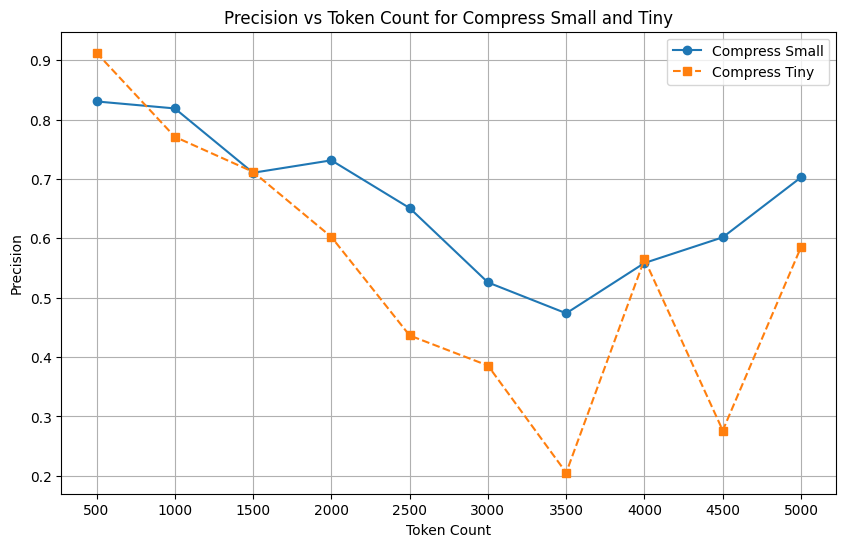

In [5]:
import matplotlib.pyplot as plt
import json

# 读取两个JSON文件
with open('../results/compress/compress_small_ocr_results_eval.json', 'r', encoding='utf-8') as f:
    small_data = json.load(f)

with open('../results/compress/compress_tiny_ocr_results_eval.json', 'r', encoding='utf-8') as f:
    tiny_data = json.load(f)

# 提取数据点（排除最后一个overall_metrics）
small_points = [(item['token_count'], item['precision']) for item in small_data[:-1]]
tiny_points = [(item['token_count'], item['precision']) for item in tiny_data[:-1]]

# 按token_count排序
small_points.sort(key=lambda x: x[0])
tiny_points.sort(key=lambda x: x[0])

# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot([x[0] for x in small_points], [x[1] for x in small_points], label='Compress Small', marker='o', linestyle='-')
plt.plot([x[0] for x in tiny_points], [x[1] for x in tiny_points], label='Compress Tiny', marker='s', linestyle='--')

plt.xlabel('Token Count')
plt.ylabel('Precision')
plt.title('Precision vs Token Count for Compress Small and Tiny')
plt.legend()
plt.grid(True)

# 调整横坐标间隔（例如，每100个token一个刻度）
max_token = max(max(x[0] for x in small_points), max(x[0] for x in tiny_points))
plt.xticks(range(500, max_token + 500, 500))

plt.show()

In [141]:
print_analysis_results("../results/compress/story_1_ocr_tiny_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9882 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.8654 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.4888 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.5417 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.5000 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.4762 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.4483 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.4519 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.4845 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.4500 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.3636 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.5062 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.3256 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.4059 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.1843 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2689 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.0000 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.0000 
Token范围 9500-9600    样本

In [142]:
print_analysis_results("../results/compress/story_2_ocr_tiny_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9640 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.7601 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.5127 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.6615 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.5385 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.6216 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.4444 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.4000 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.3333 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.4242 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.2667 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.5806 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.4832 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.2667 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2658 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.4211 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.0000 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.0000 
Token范围 9500-9600    样本

In [143]:
print_analysis_results("../results/compress/story_3_ocr_tiny_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9963 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.8747 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.0498 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.5333 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.2114 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.1250 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.4048 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.5833 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.4267 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.2393 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.1366 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.3409 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.3158 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.3023 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.0400 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2941 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.0000 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.0000 
Token范围 9500-9600    样本

In [144]:
print_analysis_results("../results/compress/story_4_ocr_tiny_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9922 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.7931 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.3982 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.4272 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.5484 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5172 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.3824 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.3333 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.3441 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.2969 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.1857 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.3881 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.2411 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.5556 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.0000 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2414 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.0000 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.0000 
Token范围 9500-9600    样本

In [145]:
print_analysis_results("../results/compress/story_5_ocr_tiny_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 1.0000 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.8044 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.4386 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.4875 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.5942 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.6800 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.5556 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.6000 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.3092 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.4041 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.2822 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.4839 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.1789 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.3151 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2667 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.3154 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.0000 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.0000 
Token范围 9500-9600    样本

In [146]:
print_analysis_results("../results/compress/story_1_ocr_small_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9843 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.9739 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.8401 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.5885 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.4769 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5882 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.4531 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.1368 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.2683 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.0890 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.3931 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.4184 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.4222 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.2947 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2530 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.3061 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.4286 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.2439 
Token范围 9500-9600    样本

In [147]:
print_analysis_results("../results/compress/story_2_ocr_small_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 1.0000 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.9362 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7863 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.5598 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.6765 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.7647 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.6667 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.5417 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.6250 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.2947 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.5200 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.2807 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.4419 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.2165 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.3273 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2661 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.3714 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.3824 
Token范围 9500-9600    样本

In [148]:
print_analysis_results("../results/compress/story_3_ocr_small_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 0.9664 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.9498 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.2368 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.5919 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.4878 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5854 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.2086 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.3548 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.5714 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.4167 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.3729 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.2472 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.4444 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.3362 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2805 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2870 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.2208 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.2680 
Token范围 9500-9600    样本

In [149]:
print_analysis_results("../results/compress/story_4_ocr_small_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 1.0000 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.9136 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7571 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.7333 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.6970 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5319 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.3491 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.4048 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.3429 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.3263 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.3165 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.2857 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.2708 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.2710 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2267 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.2397 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.3387 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.1636 
Token范围 9500-9600    样本

In [150]:
print_analysis_results("../results/compress/story_5_ocr_small_results_eval.json")

按Token数量分组的Precision统计
Token范围 500-600      样本数 =   1 平均Precision = 1.0000 
Token范围 1000-1100    样本数 =   1 平均Precision = 0.9978 
Token范围 1500-1600    样本数 =   1 平均Precision = 0.7848 
Token范围 2000-2100    样本数 =   1 平均Precision = 0.4869 
Token范围 2500-2600    样本数 =   1 平均Precision = 0.6984 
Token范围 3000-3100    样本数 =   1 平均Precision = 0.5593 
Token范围 3500-3600    样本数 =   1 平均Precision = 0.5750 
Token范围 4000-4100    样本数 =   1 平均Precision = 0.3333 
Token范围 4500-4600    样本数 =   1 平均Precision = 0.0221 
Token范围 5000-5100    样本数 =   1 平均Precision = 0.2963 
Token范围 5500-5600    样本数 =   1 平均Precision = 0.3195 
Token范围 6000-6100    样本数 =   1 平均Precision = 0.2772 
Token范围 6500-6600    样本数 =   1 平均Precision = 0.3913 
Token范围 7000-7100    样本数 =   1 平均Precision = 0.1370 
Token范围 7500-7600    样本数 =   1 平均Precision = 0.2410 
Token范围 8000-8100    样本数 =   1 平均Precision = 0.3333 
Token范围 8500-8600    样本数 =   1 平均Precision = 0.3130 
Token范围 9000-9100    样本数 =   1 平均Precision = 0.2500 
Token范围 9500-9600    样本

### 压缩比绘图

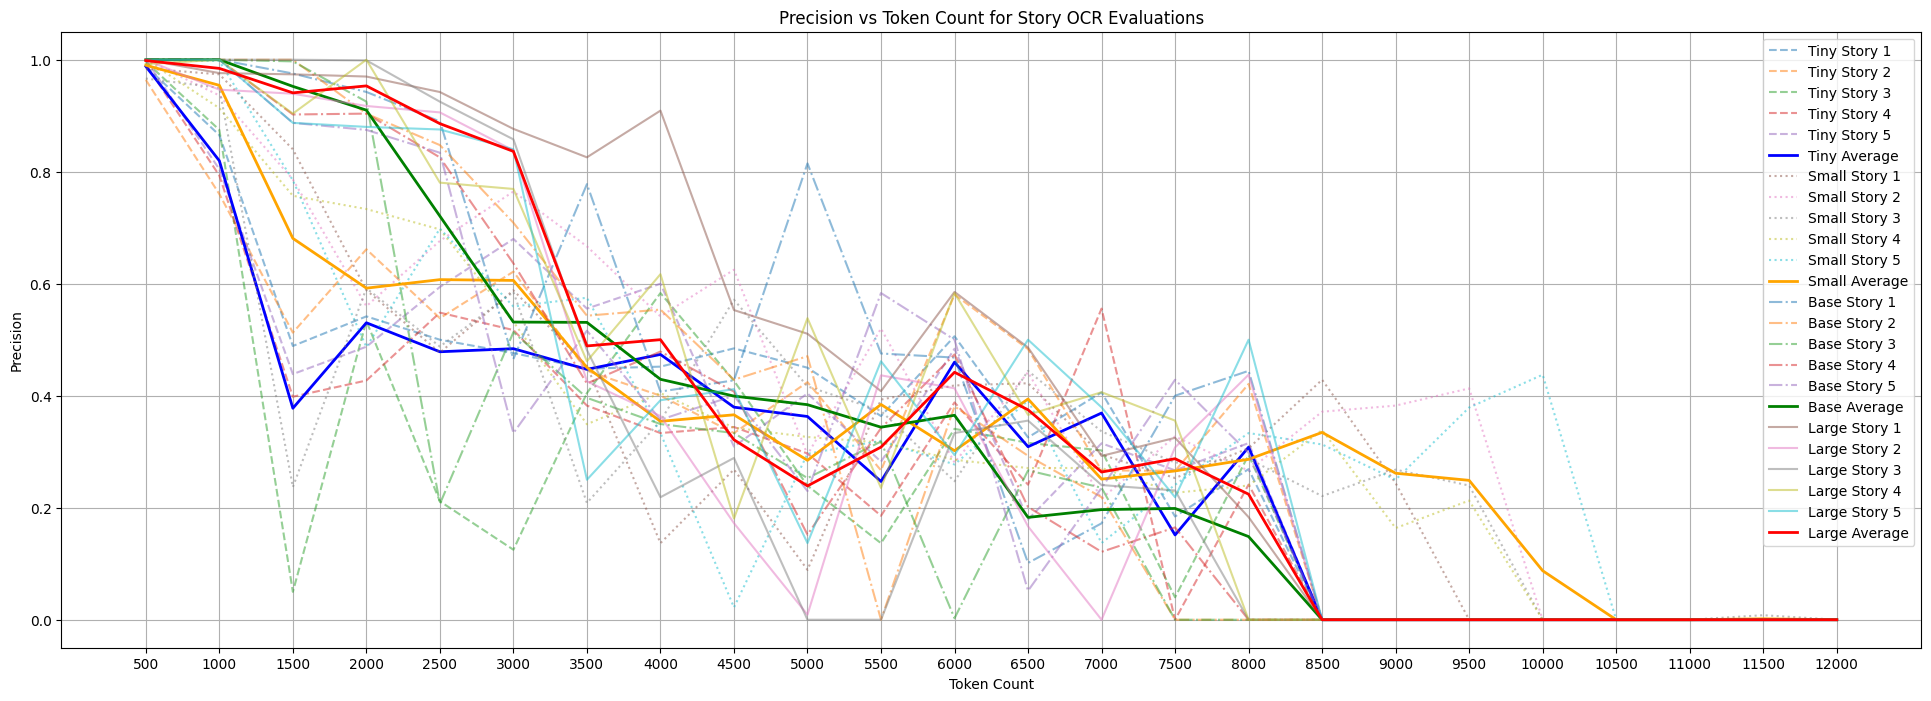

In [6]:
# 将上面10个评估文件的结果以及平均结果绘制成折线图
import matplotlib.pyplot as plt
import json
import numpy as np
def load_evaluation_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    points = [(item['token_count'], item['precision']) for item in data[:-1]]
    points.sort(key=lambda x: x[0])
    return points
file_paths = [
    "../results/compress/story_1_ocr_tiny_results_eval.json",
    "../results/compress/story_2_ocr_tiny_results_eval.json",
    "../results/compress/story_3_ocr_tiny_results_eval.json",
    "../results/compress/story_4_ocr_tiny_results_eval.json",
    "../results/compress/story_5_ocr_tiny_results_eval.json",
    "../results/compress/story_1_ocr_small_results_eval.json",
    "../results/compress/story_2_ocr_small_results_eval.json",
    "../results/compress/story_3_ocr_small_results_eval.json",
    "../results/compress/story_4_ocr_small_results_eval.json",
    "../results/compress/story_5_ocr_small_results_eval.json",
    "../results/compress/story_1_ocr_base_results_eval.json",
    "../results/compress/story_2_ocr_base_results_eval.json",
    "../results/compress/story_3_ocr_base_results_eval.json",
    "../results/compress/story_4_ocr_base_results_eval.json",
    "../results/compress/story_5_ocr_base_results_eval.json",
    "../results/compress/story_1_ocr_large_results_eval.json",
    "../results/compress/story_2_ocr_large_results_eval.json",
    "../results/compress/story_3_ocr_large_results_eval.json",
    "../results/compress/story_4_ocr_large_results_eval.json",
    "../results/compress/story_5_ocr_large_results_eval.json",
]
# 按照tiny和small分开存储数据
tiny_data = []
small_data = []
base_data = []
large_data = []
for file_path in file_paths:
    points = load_evaluation_data(file_path)
    if "tiny" in file_path:
        tiny_data.append(points)
    elif "small" in file_path:
        small_data.append(points)
    elif "base" in file_path:
        base_data.append(points)
    elif "large" in file_path:
        large_data.append(points)
# 计算平均数据点
def compute_average_data(data_list):
    max_length = max(len(data) for data in data_list)
    avg_data = []
    for i in range(max_length):
        token_counts = []
        precisions = []
        for data in data_list:
            if i < len(data):
                token_counts.append(data[i][0])
                precisions.append(data[i][1])
        if token_counts:
            avg_token_count = int(np.mean(token_counts))
            avg_precision = np.mean(precisions)
            avg_data.append((avg_token_count, avg_precision))
    return avg_data
avg_tiny_data = compute_average_data(tiny_data)
avg_small_data = compute_average_data(small_data)
avg_base_data = compute_average_data(base_data)
avg_large_data = compute_average_data(large_data)
# 将所有数据截断到12000个token
def truncate_data(data, max_token=12000):
    truncated_data = []
    for point in data:
        if point[0] <= max_token:
            truncated_data.append(point)
    return truncated_data
tiny_data = [truncate_data(data) for data in tiny_data]
small_data = [truncate_data(data) for data in small_data]
base_data = [truncate_data(data) for data in base_data]
large_data = [truncate_data(data) for data in large_data]
avg_tiny_data = truncate_data(avg_tiny_data)
avg_small_data = truncate_data(avg_small_data)
avg_base_data = truncate_data(avg_base_data)
avg_large_data = truncate_data(avg_large_data)
# 绘制折线图
plt.figure(figsize=(24, 8))
# 绘制tiny数据
for i, data in enumerate(tiny_data):
    plt.plot([x[0] for x in data], [x[1] for x in data], label=f'Tiny Story {i+1}', linestyle='--', alpha=0.5)
plt.plot([x[0] for x in avg_tiny_data], [x[1] for x in avg_tiny_data], label='Tiny Average', color='blue', linewidth=2)
# 绘制small数据
for i, data in enumerate(small_data):
    plt.plot([x[0] for x in data], [x[1] for x in data], label=f'Small Story {i+1}', linestyle=':', alpha=0.5)
plt.plot([x[0] for x in avg_small_data], [x[1] for x in avg_small_data], label='Small Average', color='orange', linewidth=2)
# 绘制base数据
for i, data in enumerate(base_data):
    plt.plot([x[0] for x in data], [x[1] for x in data], label=f'Base Story {i+1}', linestyle='-.', alpha=0.5)
plt.plot([x[0] for x in avg_base_data], [x[1] for x in avg_base_data], label='Base Average', color='green', linewidth=2)
# 绘制large数据
for i, data in enumerate(large_data):
    plt.plot([x[0] for x in data], [x[1] for x in data], label=f'Large Story {i+1}', linestyle='-', alpha=0.5)
plt.plot([x[0] for x in avg_large_data], [x[1] for x in avg_large_data], label='Large Average', color='red', linewidth=2)
plt.xlabel('Token Count')
plt.ylabel('Precision')
plt.title('Precision vs Token Count for Story OCR Evaluations')
plt.legend()
plt.grid(True)
# 调整横坐标间隔（例如，每100个token一个刻度）
max_token = max(max(x[0] for x in avg_tiny_data), max(x[0] for x in avg_small_data))
plt.xticks(range(500, max_token + 500, 500))
plt.savefig('./compress.pdf')
plt.show()

In [7]:

story_index = 1
for item in avg_tiny_data:
    token_coount, precision = item
    print(f"Story {story_index} Tiny - Token Count: {token_coount}, Precision: {precision:.4f}")
    if token_coount >= 20000:
        story_index += 1
story_index = 1
for item in avg_small_data:
    token_coount, precision = item
    print(f"Story {story_index} Small - Token Count: {token_coount}, Precision: {precision:.4f}")
    if token_coount >= 20000:
        story_index += 1
story_index = 1
for item in avg_base_data:
    token_coount, precision = item
    print(f"Story {story_index} Base - Token Count: {token_coount}, Precision: {precision:.4f}")
    if token_coount >= 20000:
        story_index += 1
story_index = 1
for item in avg_large_data:
    token_coount, precision = item
    print(f"Story {story_index} Large - Token Count: {token_coount}, Precision: {precision:.4f}")
    if token_coount >= 20000:
        story_index += 1

Story 1 Tiny - Token Count: 500, Precision: 0.9881
Story 1 Tiny - Token Count: 1000, Precision: 0.8196
Story 1 Tiny - Token Count: 1500, Precision: 0.3776
Story 1 Tiny - Token Count: 2000, Precision: 0.5302
Story 1 Tiny - Token Count: 2500, Precision: 0.4785
Story 1 Tiny - Token Count: 3000, Precision: 0.4840
Story 1 Tiny - Token Count: 3500, Precision: 0.4471
Story 1 Tiny - Token Count: 4000, Precision: 0.4737
Story 1 Tiny - Token Count: 4500, Precision: 0.3796
Story 1 Tiny - Token Count: 5000, Precision: 0.3629
Story 1 Tiny - Token Count: 5500, Precision: 0.2469
Story 1 Tiny - Token Count: 6000, Precision: 0.4599
Story 1 Tiny - Token Count: 6500, Precision: 0.3089
Story 1 Tiny - Token Count: 7000, Precision: 0.3691
Story 1 Tiny - Token Count: 7500, Precision: 0.1514
Story 1 Tiny - Token Count: 8000, Precision: 0.3082
Story 1 Tiny - Token Count: 8500, Precision: 0.0000
Story 1 Tiny - Token Count: 9000, Precision: 0.0000
Story 1 Tiny - Token Count: 9500, Precision: 0.0000
Story 1 Tiny 

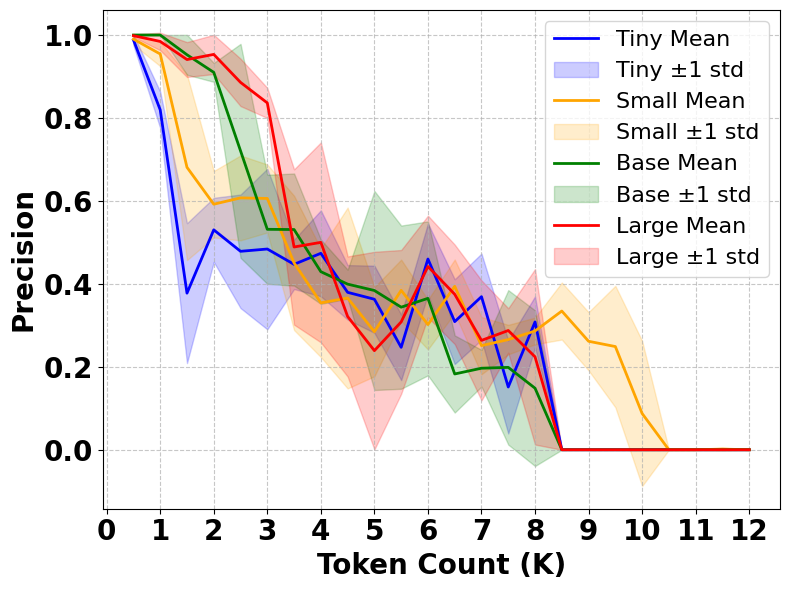

In [18]:
# 计算均值和标准差并绘制误差带图
def get_stats(data_list):
    from collections import defaultdict
    points_by_x = defaultdict(list)
    for data in data_list:
        for x, y in data:
            points_by_x[x].append(y)
    
    sorted_x = sorted(points_by_x.keys())
    means = [np.mean(points_by_x[x]) for x in sorted_x]
    stds = [np.std(points_by_x[x]) for x in sorted_x]
    return np.array(sorted_x), np.array(means), np.array(stds)

plt.figure(figsize=(8, 6))

configs = [
    (tiny_data, 'Tiny', 'blue'),
    (small_data, 'Small', 'orange'),
    (base_data, 'Base', 'green'),
    (large_data, 'Large', 'red')
]

for data, label, color in configs:
    if not data:
        continue
    x, mean, std = get_stats(data)
    plt.plot(x, mean, label=f'{label} Mean', color=color, linewidth=2)
    # 绘制误差带 (均值 ± 标准差)
    plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.2, label=f'{label} ±1 std')

# 调整字体大小
plt.xlabel('Token Count (K)', fontsize=20, fontweight='bold') # 横坐标标签
plt.ylabel('Precision', fontsize=20,fontweight='bold')   # 纵坐标标签
# plt.title('Precision vs Token Count with Error Bands', fontsize=20) # 标题
plt.legend(loc='upper right', fontsize=16, ) # 图例位置调整为右上角
plt.grid(True, linestyle='--', alpha=0.7)

# 统一横坐标刻度并调整刻度字体
all_x = []
for d, _, _ in configs:
    if d:
        for sub_d in d:
            all_x.extend([p[0] for p in sub_d])
if all_x:
    ticks = range(0, int(max(all_x)) + 1000, 1000)
    plt.xticks(ticks, [f'{t//1000}' for t in ticks], fontsize=20, fontweight='bold') # 将数值除以1000显示（加粗）
plt.yticks(fontsize=20, fontweight='bold') # 纵坐标刻度（加粗）

plt.tight_layout()
plt.savefig('./compress_error_band.pdf')
plt.show()

# 绘制VQA和QA

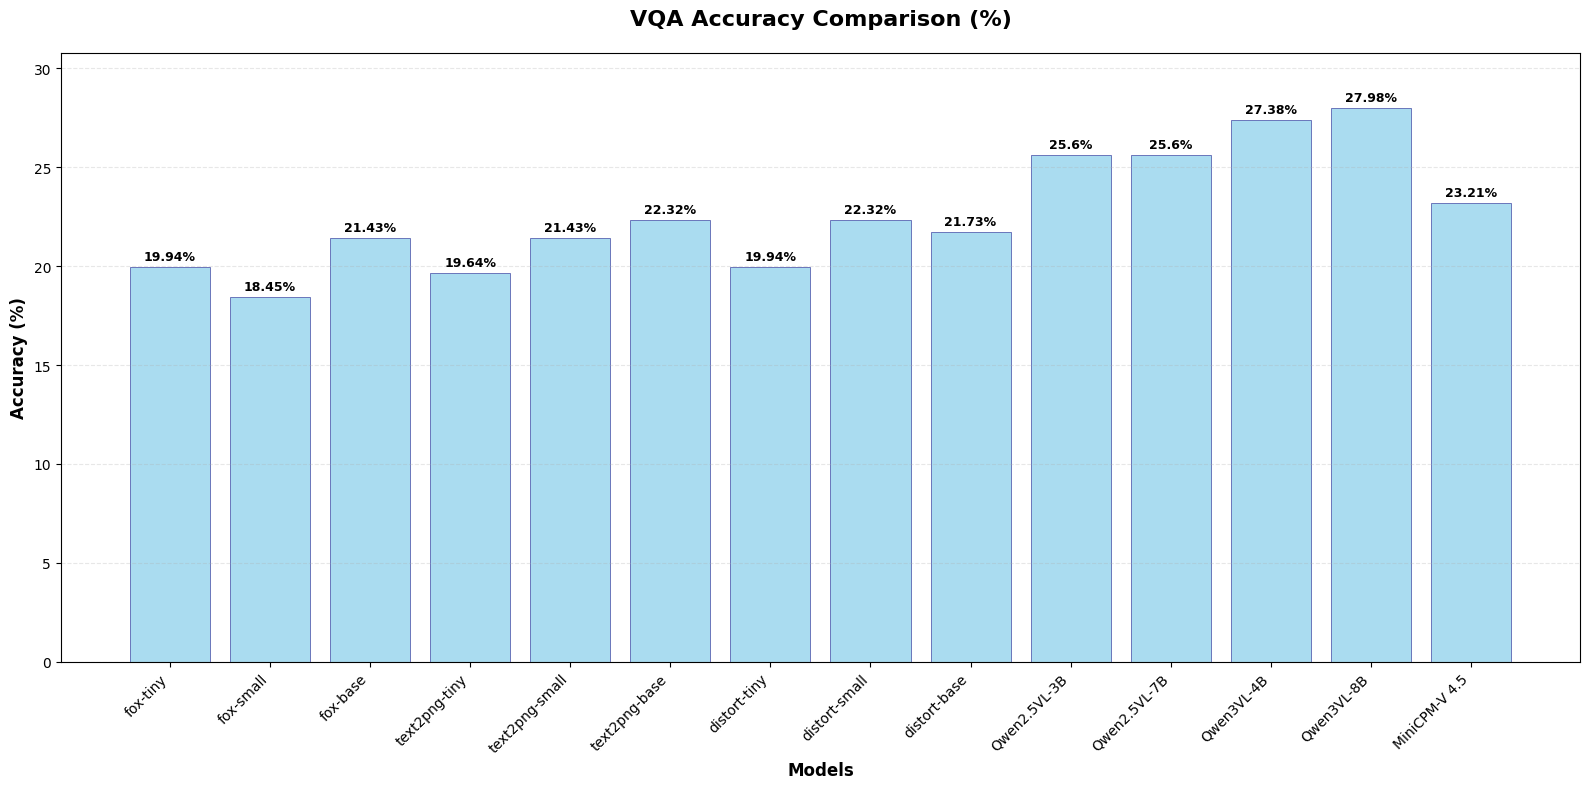

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
models = [
    'fox-tiny', 'fox-small', 'fox-base',
    'text2png-tiny', 'text2png-small', 'text2png-base',
    'distort-tiny', 'distort-small', 'distort-base',
    'Qwen2.5VL-3B', 'Qwen2.5VL-7B',
    'Qwen3VL-4B', 'Qwen3VL-8B',
    'MiniCPM-V 4.5'
]

accuracy = [19.94, 18.45, 21.43, 19.64, 21.43, 22.32, 
           19.94, 22.32, 21.73, 25.60, 25.60, 27.38, 27.98, 23.21]

# 创建图形
plt.figure(figsize=(16, 8))

# 创建柱状图 - 使用单一颜色
bars = plt.bar(models, accuracy, color='skyblue', alpha=0.7, edgecolor='navy', linewidth=0.5)

# 在柱子上添加数值标签
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 设置标题和标签
plt.title('VQA Accuracy Comparison (%)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Models', fontsize=12, fontweight='bold')

# 旋转x轴标签以避免重叠
plt.xticks(rotation=45, ha='right')

# 添加网格线
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# 调整y轴范围
plt.ylim(0, max(accuracy) * 1.1)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

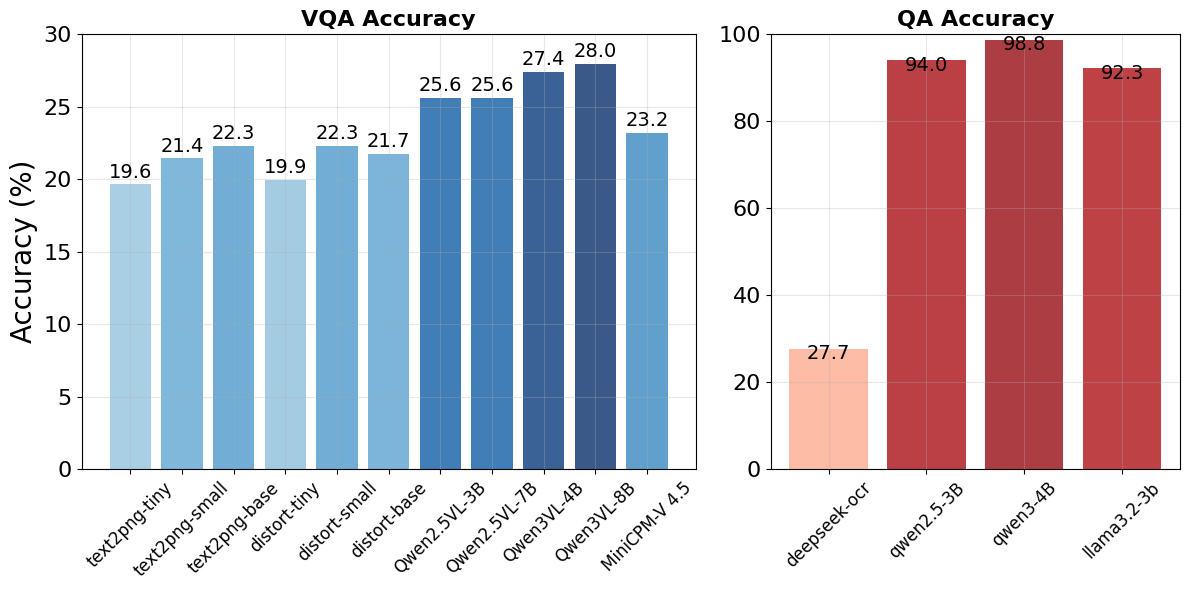

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建图形
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 2]})

# ==================== VQA子图（简化版）====================
vqa_models = ['text2png-tiny', 'text2png-small', 
               'text2png-base', 'distort-tiny', 'distort-small', 'distort-base', 
               'Qwen2.5VL-3B', 'Qwen2.5VL-7B', 'Qwen3VL-4B', 'Qwen3VL-8B', 'MiniCPM-V 4.5']
vqa_accuracy = [19.64, 21.43, 22.32, 19.94, 22.32, 21.73, 25.60, 25.60, 27.38, 27.98, 23.21]

# 将准确率归一化，使颜色深浅代表数值高低
vqa_acc_np = np.array(vqa_accuracy)
vqa_norm = (vqa_acc_np - vqa_acc_np.min()) / (vqa_acc_np.max() - vqa_acc_np.min())
colors_vqa = plt.cm.Blues(vqa_norm * 0.6 + 0.4) # 映射到 [0.4, 1.0] 区间

bars1 = ax1.bar(vqa_models, vqa_accuracy, color=colors_vqa, alpha=0.8)
ax1.set_title('VQA Accuracy', fontsize=16, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=20)
ax1.set_ylim(0, 30)
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.tick_params(axis='y',labelsize=16)
ax1.grid(True, alpha=0.3)

# 添加数值标签
for bar, acc in zip(bars1, vqa_accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{acc:.1f}', ha='center', va='bottom', fontsize=14)

# ==================== QA子图（简化版）====================
qa_models = ['deepseek-ocr', 'qwen2.5-3B', 'qwen3-4B', 'llama3.2-3b']
qa_accuracy = [27.68, 94.05, 98.81, 92.26]

# 使用数据自身的最小值和最大值进行归一化，使颜色对比度最大化
acc_np = np.array(qa_accuracy)
norm_acc = (acc_np - acc_np.min()) / (acc_np.max() - acc_np.min())
# 将归一化后的 [0, 1] 映射到 Reds 颜色条的 [0.3, 0.9] 区间，确保颜色既不过浅也不过深
colors_qa = plt.cm.Reds(norm_acc * 0.6 + 0.3)

bars2 = ax2.bar(qa_models, qa_accuracy, color=colors_qa, alpha=0.8)
ax2.set_title('QA Accuracy', fontsize=16, fontweight='bold')

# ax2.set_ylabel('Accuracy (%)', fontsize=16)
ax2.tick_params(axis='x', rotation=45, labelsize=12)
ax2.tick_params(axis='y',labelsize=16)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100) # 调高上限到 115，为顶部的数值标签留出空间

# 添加数值标签
for bar, acc in zip(bars2, qa_accuracy):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}', ha='center', va='top', fontsize=14)

# 整体标题
# fig.suptitle('Model Performance Comparison: VQA and QA Tasks', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('./vqa_qa.pdf')

plt.show()

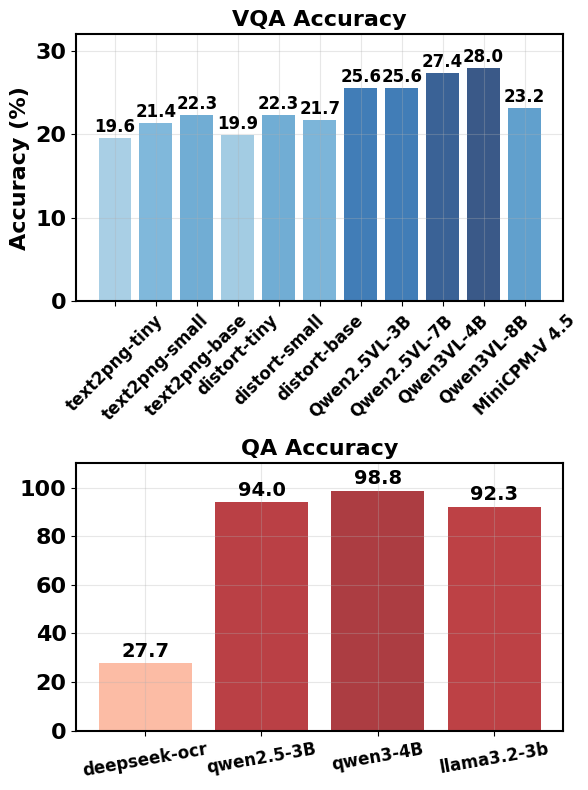

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建图形, 上下子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# ==================== VQA子图（简化版）====================
vqa_models = ['text2png-tiny', 'text2png-small', 
               'text2png-base', 'distort-tiny', 'distort-small', 'distort-base', 
               'Qwen2.5VL-3B', 'Qwen2.5VL-7B', 'Qwen3VL-4B', 'Qwen3VL-8B', 'MiniCPM-V 4.5']
vqa_accuracy = [19.64, 21.43, 22.32, 19.94, 22.32, 21.73, 25.60, 25.60, 27.38, 27.98, 23.21]

# 将准确率归一化，使颜色深浅代表数值高低
vqa_acc_np = np.array(vqa_accuracy)
vqa_norm = (vqa_acc_np - vqa_acc_np.min()) / (vqa_acc_np.max() - vqa_acc_np.min())
colors_vqa = plt.cm.Blues(vqa_norm * 0.6 + 0.4) # 映射到 [0.4, 1.0] 区间

bars1 = ax1.bar(vqa_models, vqa_accuracy, color=colors_vqa, alpha=0.8)
ax1.set_title('VQA Accuracy', fontsize=16, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=16, fontweight='bold')
ax1.set_ylim(0,32)
ax1.tick_params(axis='x', rotation=45, labelsize=12,)
ax1.tick_params(axis='y',labelsize=16)
ax1.grid(True, alpha=0.3)

for lbl in ax1.get_xticklabels():
    lbl.set_fontweight('bold')

for lbl in ax1.get_yticklabels():
    lbl.set_fontweight('bold')
    
for sp in ax1.spines.values():
    sp.set_linewidth(1.5)

# 添加数值标签
for bar, acc in zip(bars1, vqa_accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ==================== QA子图（简化版）====================
qa_models = ['deepseek-ocr', 'qwen2.5-3B', 'qwen3-4B', 'llama3.2-3b']
qa_accuracy = [27.68, 94.05, 98.81, 92.26]

# 使用数据自身的最小值和最大值进行归一化，使颜色对比度最大化
acc_np = np.array(qa_accuracy)
norm_acc = (acc_np - acc_np.min()) / (acc_np.max() - acc_np.min())
# 将归一化后的 [0, 1] 映射到 Reds 颜色条的 [0.3, 0.9] 区间，确保颜色既不过浅也不过深
colors_qa = plt.cm.Reds(norm_acc * 0.6 + 0.3)

bars2 = ax2.bar(qa_models, qa_accuracy, color=colors_qa, alpha=0.8)
ax2.set_title('QA Accuracy', fontsize=16, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=16, fontweight='bold')
# ax2.set_ylabel('Accuracy (%)', fontsize=16)
ax2.tick_params(axis='x', rotation=10, labelsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 110) # 调高上限到 115，为顶部的数值标签留出空间
ax2.tick_params(axis='y',labelsize=16)

for lbl in ax2.get_xticklabels():
    lbl.set_fontweight('bold')

for lbl in ax2.get_yticklabels():
    lbl.set_fontweight('bold')

# 添加数值标签
for bar, acc in zip(bars2, qa_accuracy):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

for sp in ax2.spines.values():
    sp.set_linewidth(1.5)

# 整体标题
# fig.suptitle('Model Performance Comparison: VQA and QA Tasks', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig('./vqa_qa.pdf')

plt.show()